In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        (os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [6]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import cv2

In [7]:
DATASET_PATH = "/kaggle/input/datasets/amimulahasanrofik/alz-b-1100/alzheimer_new_11/alzheimer_new"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = 8

EPOCHS_STAGE1 = 10
EPOCHS_STAGE2 = 10

AUTOTUNE = tf.data.AUTOTUNE

In [8]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

Found 8800 files belonging to 8 classes.
Using 7040 files for training.


I0000 00:00:1775105024.385098      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 8800 files belonging to 8 classes.
Using 1760 files for validation.
['MildDemented', 'Moderate Dementia', 'NonDemented', 'Very mild Dementia', 'glioma', 'meningioma', 'notumor', 'pituitary']


In [9]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.3),
])

In [10]:
def transformer_block(x):
    dim = x.shape[-1]

    x1 = layers.LayerNormalization()(x)
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=dim)(x1, x1)
    x2 = layers.Add()([attn, x])

    x3 = layers.LayerNormalization()(x2)
    x3 = layers.Dense(dim*2, activation="gelu")(x3)
    x3 = layers.Dense(dim)(x3)

    return layers.Add()([x3, x2])

In [11]:
def transformer_block(x):
    dim = x.shape[-1]

    x1 = layers.LayerNormalization()(x)
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=dim)(x1, x1)
    x2 = layers.Add()([attn, x])

    x3 = layers.LayerNormalization()(x2)
    x3 = layers.Dense(dim*2, activation="gelu")(x3)
    x3 = layers.Dense(dim)(x3)

    return layers.Add()([x3, x2])

In [13]:
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=IMG_SIZE + (3,),
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

# FIX: reshape properly for transformer
x = layers.Reshape((1, x.shape[-1]))(x)

# transformer
x = transformer_block(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ sequential[0][0]  │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 2048)   │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 2048)   │      4,096 │ reshape[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 2048)   │ 67,135,488 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 2048)   │          0 │ multi_head_atten… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 2048)   │      4,096 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 4096)   │  8,392,704 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 2048)   │  8,390,656 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 2048)   │          0 │ dense_1[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2048)      │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    262,272 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 8)         │      1,032 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 107,778,056 (411.14 MB)

 Trainable params: 84,190,344 (321.16 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=3)
]

In [16]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks
)

Epoch 1/10


I0000 00:00:1775105124.872191     158 cuda_dnn.cc:529] Loaded cuDNN version 91002


220/220 ━━━━━━━━━━━━━━━━━━━━ 71s 176ms/step - accuracy: 0.6152 - loss: 1.1845 - val_accuracy: 0.7801 - val_loss: 0.6310 - learning_rate: 1.0000e-04
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 33s 148ms/step - accuracy: 0.8043 - loss: 0.5094 - val_accuracy: 0.8614 - val_loss: 0.3918 - learning_rate: 1.0000e-04
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 32s 148ms/step - accuracy: 0.8387 - loss: 0.4466 - val_accuracy: 0.8665 - val_loss: 0.3704 - learning_rate: 1.0000e-04
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 32s 145ms/step - accuracy: 0.8620 - loss: 0.3791 - val_accuracy: 0.8517 - val_loss: 0.3994 - learning_rate: 1.0000e-04
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 33s 148ms/step - accuracy: 0.8802 - loss: 0.3196 - val_accuracy: 0.9023 - val_loss: 0.2753 - learning_rate: 1.0000e-04
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 32s 145ms/step - accuracy: 0.8813 - loss: 0.3146 - val_accuracy: 0.8341 - val_loss: 0.5283 - learning_rate: 1.0000e-04
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 32s 145ms/step - 

In [17]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks
)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 57s 182ms/step - accuracy: 0.8241 - loss: 0.8171 - val_accuracy: 0.8830 - val_loss: 0.4159 - learning_rate: 1.0000e-05
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 36s 166ms/step - accuracy: 0.9115 - loss: 0.2573 - val_accuracy: 0.8875 - val_loss: 0.3509 - learning_rate: 1.0000e-05
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 36s 162ms/step - accuracy: 0.9227 - loss: 0.2166 - val_accuracy: 0.8869 - val_loss: 0.4186 - learning_rate: 1.0000e-05
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 36s 162ms/step - accuracy: 0.9348 - loss: 0.1683 - val_accuracy: 0.8898 - val_loss: 0.3602 - learning_rate: 1.0000e-05
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 36s 165ms/step - accuracy: 0.9475 - loss: 0.1450 - val_accuracy: 0.9074 - val_loss: 0.3370 - learning_rate: 1.0000e-05
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 36s 165ms/step - accuracy: 0.9506 - loss: 0.1321 - val_accuracy: 0.9159 - val_loss: 0.2675 - learning_rate: 1.0000e-05
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 36s 16

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━

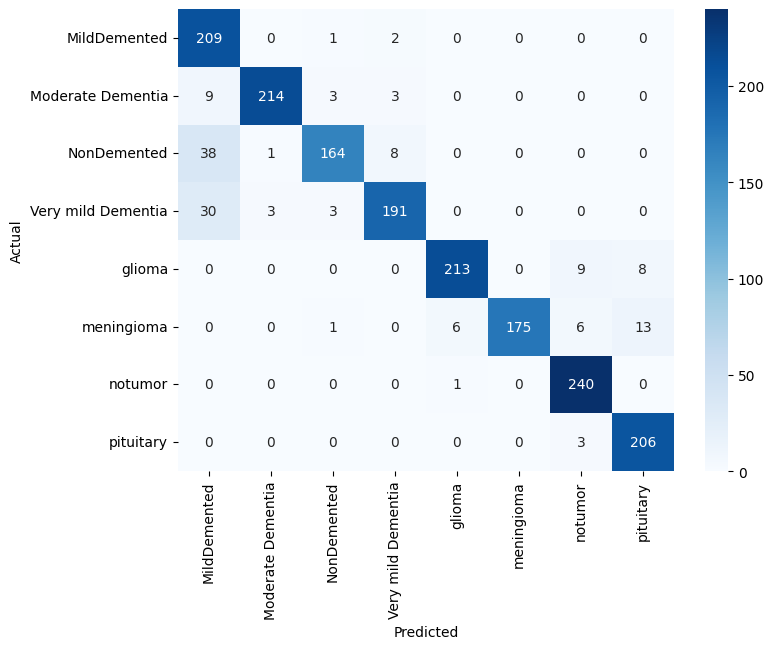

In [18]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
last_conv_layer_name = "conv5_block3_out"

def make_gradcam_heatmap(img_array):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

In [20]:
for images, labels in val_ds.take(1):
    img = images[0]
    img_array = tf.expand_dims(img, axis=0)

    heatmap = make_gradcam_heatmap(img_array)

    img = img.numpy().astype("uint8")
    heatmap = cv2.resize(heatmap, (128,128))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = heatmap * 0.4 + img

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(superimposed.astype("uint8"))
    plt.title("GradCAM")

    plt.show()

ValueError: No such layer: conv5_block3_out. Existing layers are: ['input_layer_1', 'sequential', 'resnet50', 'global_average_pooling2d', 'reshape', 'layer_normalization', 'multi_head_attention', 'add', 'layer_normalization_1', 'dense', 'dense_1', 'add_1', 'flatten', 'dense_2', 'dense_3'].